Name: Lien Bradley, 22201598 

Chosen language: German

Description: German news in 2021 with 30K words, file size 10.3MB. 

    "Used text material was taken from news webstires (typically on a daily basis via RSS feeds"
    URL: https://wortschatz.uni-leipzig.de/en/download/German#deu_news_2021 (corpus used is under News subsection, year 2021, with 30K words)

In [147]:
import nltk
import nltk.data
from nltk.corpus.reader import PlaintextCorpusReader
from nltk.text import Text
from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.probability import FreqDist
from nltk import CFG
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import sentencepiece as spm
from collections import Counter

In [113]:
# Loading corpus
corpus_root = 'C:/Users/libra/PycharmProjects/NLP/.venv/data/deu_news_2021_30K'
corpus = PlaintextCorpusReader(corpus_root, 'deu_news_2021_30K-sentences.txt')
plaintext = corpus.raw().lower()
sentences = corpus.sents('deu_news_2021_30K-sentences.txt')

# Downloading nltk module
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\libra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [114]:
# Task 4
# Calculate lexical richness 
words = corpus.words()
unique_words = set(words)
lexical_diversity = len(unique_words) / len(words)
print(lexical_diversity)

0.15911464128592703


[('e', 433478), ('n', 267744), ('i', 213403), ('r', 199049), ('t', 171587), ('s', 168504), ('a', 161645), ('d', 128652), ('h', 110527), ('u', 100279)]


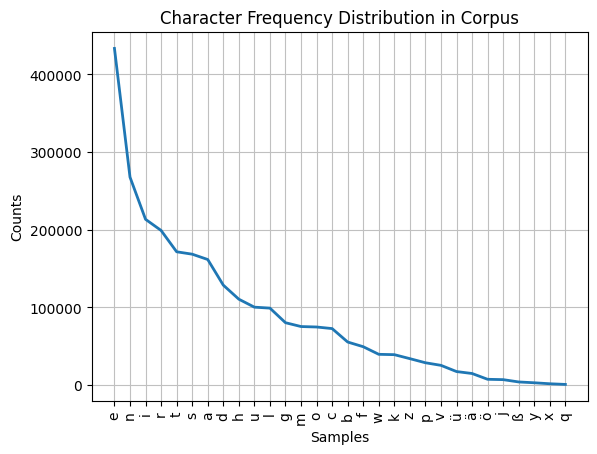

<Axes: title={'center': 'Character Frequency Distribution in Corpus'}, xlabel='Samples', ylabel='Counts'>

In [125]:
# Task 5
# preprocess text
re_tokenizer = RegexpTokenizer(r'\w+')
text_no_punct = re_tokenizer.tokenize(plaintext)
text_sans_numbers = ' '.join(text_words)
text_words = [word for word in text_no_punct if word.isalpha()]

# Character distribution of corpus
chars = [char for sentence in text_words for word in sentence for char in word]
fdist1 = FreqDist(chars)
print(fdist1.most_common(10))
fdist1.plot(30, title='Character Frequency Distribution in Corpus')  # German alphabet has 30 letters


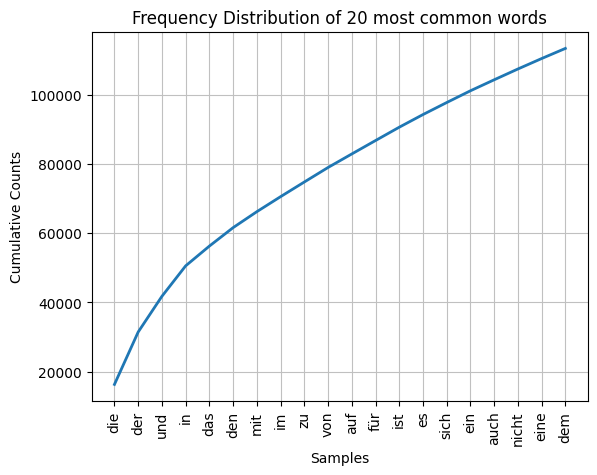

<Axes: title={'center': 'Frequency Distribution of 20 most common words'}, xlabel='Samples', ylabel='Cumulative Counts'>

In [126]:
# Task 6
# Word distribution of 20 most often used words
fdist2 = FreqDist(text_words)
fdist2.plot(20, cumulative=True, title="Frequency Distribution of 20 most common words")

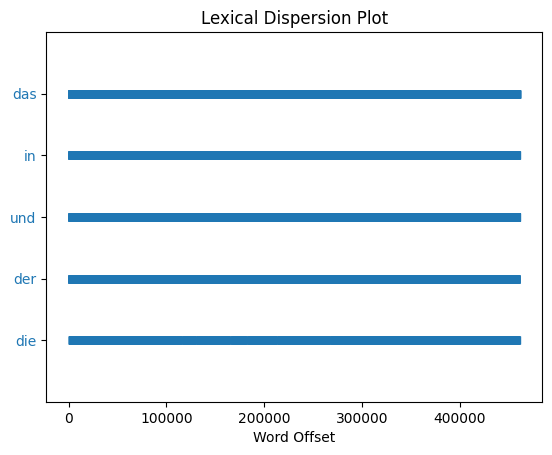

In [124]:
# Task 7
# create Text object
text_obj = nltk.Text(text_words)

# Show dispersion of 5 most used words
common_words = fdist2.most_common(5)
common_words = [word for word, _ in common_words]
text_obj.dispersion_plot(common_words)
plt.show()

In [121]:
# Task 8
# find longest word
longest_word = max(unique_words, key=len)
print("Longest word:", longest_word)

# store as a plaintext file
with open("text.txt", "w", encoding="utf-8") as file:
    file.write(plaintext)
    
# train sentencepiece model
if not os.path.isfile('m.model'):
    spm.SentencePieceTrainer.train('--input=text.txt --model_prefix=m --vocab_size=10000')
sp = spm.SentencePieceProcessor()
sp.load('m.model')

print(sp.encode_as_pieces(longest_word))

Longest word: Lieferkettensorgfaltspflichtengesetz
['▁', 'L', 'ie', 'fer', 'k', 'ett', 'en', 's', 'org', 'f', 'al', 't', 's', 'pflicht', 'en', 'gesetz']


In [131]:
# Task 9
# preprocess the sentences
pattern = r'^\d+\t.'
lines = plaintext.strip().split('\n')
cleaned_lines = []
for line in lines:
    cleaned_line = re.sub(pattern, '', line, count=1)
    # Remove the first character if it isn't a letter
    if cleaned_line and not cleaned_line[0].isalpha():
        cleaned_line = cleaned_line[1:]
    cleaned_lines.append(cleaned_line)

# choose sentence with plus/minus 5 words
chosen_sentence = ''
for s in cleaned_lines:
    if 4 <= len(s.split()) <= 6:
        chosen_sentence = s
        # print(chosen_sentence)
        break

chosen_sentence = 'am 26. september 2021 sind bundestagswahlen'

# Define the grammar
sent_cfg = CFG.fromstring("""
    S -> PP VP
    PP -> P DATE
    DATE -> NUM MONTH YEAR
    VP -> V NP
    NP -> N
    P -> "am"
    NUM -> "26."
    MONTH -> "september"
    YEAR -> "2021"
    V -> "sind"
    N -> "bundestagswahlen"
""")
# Parsing sentence to validate grammar
parser = nltk.ChartParser(sent_cfg)
for tree in parser.parse(chosen_sentence.split()):
    print(tree)
    tree.pretty_print()

(S
  (PP (P am) (DATE (NUM 26.) (MONTH september) (YEAR 2021)))
  (VP (V sind) (NP (N bundestagswahlen))))
                S                                   
          ______|________________                    
         PP                      VP                 
  _______|______             ____|_________          
 |             DATE         |              NP       
 |    __________|______     |              |         
 P  NUM       MONTH   YEAR  V              N        
 |   |          |      |    |              |         
 am 26.     september 2021 sind     bundestagswahlen



In [138]:
# Task 10
# stem words in the chosen sentence
stemmer = SnowballStemmer('german')
stemmed_words = []
for w in chosen_sentence.split():
    stemmed_w = stemmer.stem(w)
    stemmed_words.append(stemmed_w)
print(stemmed_words)

['am', '26.', 'septemb', '2021', 'sind', 'bundestagswahl']


In [146]:
# Task 11

# need to install model first using the following command
# python -m spacy download de_core_news_sm
nlp = spacy.load("de_core_news_sm")

# lemmatize sentence
doc = nlp(chosen_sentence)
lemmatized_tokens = [token.lemma_ for token in doc]
lemmatized_text = ' '.join(lemmatized_tokens)
print(lemmatized_text)

an 26. September 2021 sein Bundestagswahl


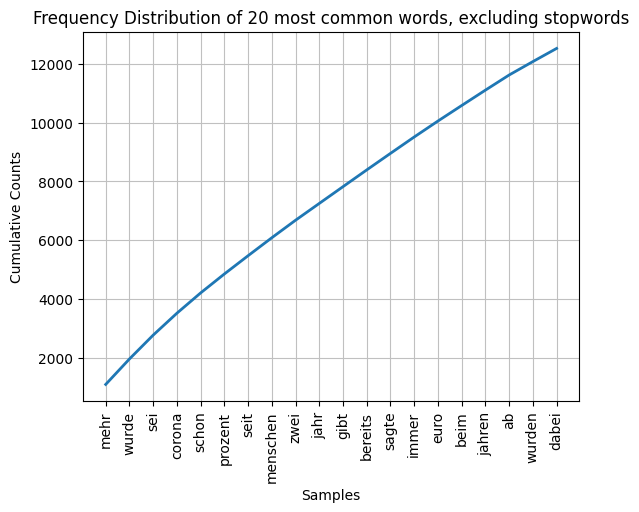

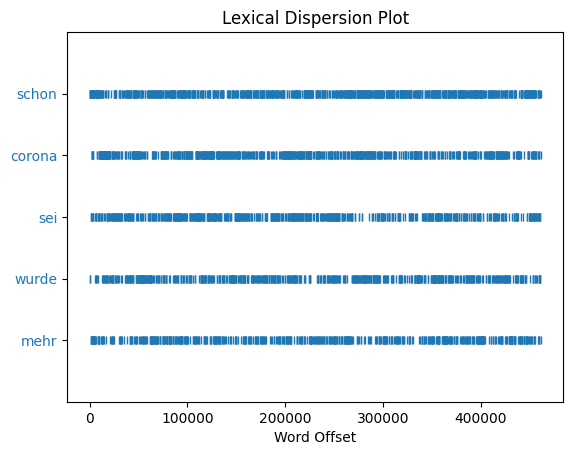

In [135]:
# Task 12
# filter out stopwords
stopwords = set(nltk.corpus.stopwords.words('german'))
filtered_words = [w for w in text_words if w.casefold() not in stopwords]

# plot distribution of 20 most used words, excluding stopwords
fdist3 = FreqDist(filtered_words)
fdist3.plot(20, cumulative=True, title="Frequency Distribution of 20 most common words, excluding stopwords")

# plot dispersion of 5 most used words
common_words2 = fdist3.most_common(5)
common_words2 = [word for word, _ in common_words2]
text_obj.dispersion_plot(common_words2)
plt.show()

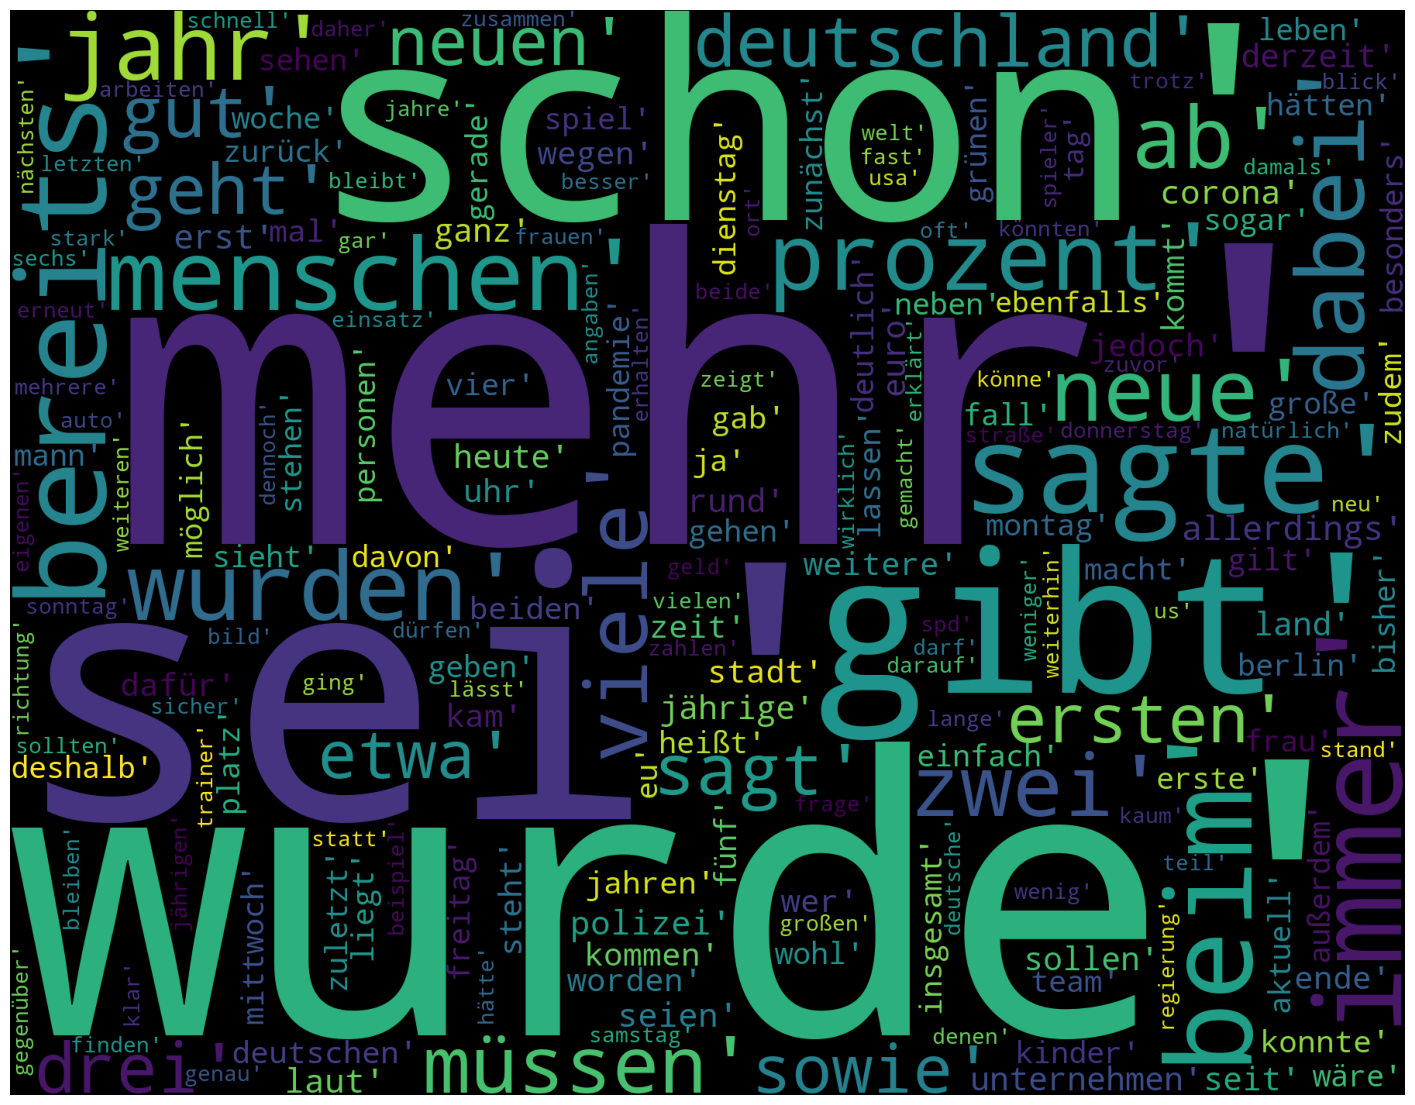

In [149]:
# Task 13
# creating a wordcloud
width = 18
height = 18
plt.figure(figsize=(width, height))
wordcloud = WordCloud(width=1800,height=1400).generate(str(filtered_words))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()